Simülasyon başlatılıyor...
Simülasyon tamamlandı. Grafik çiziliyor...


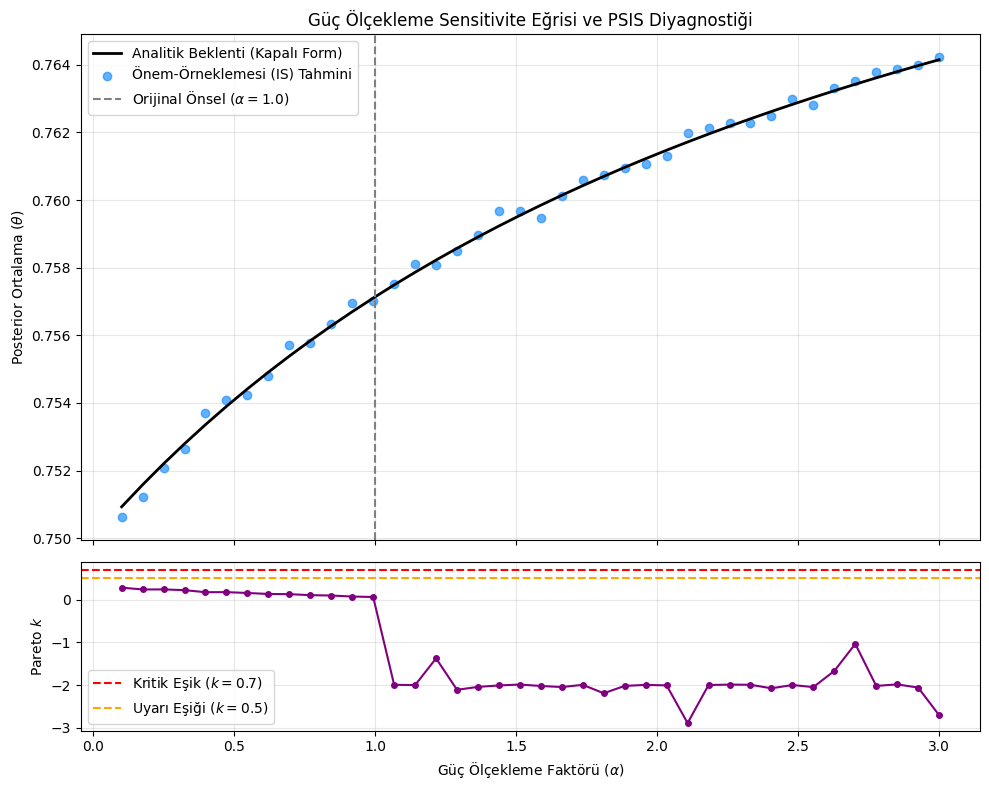

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

# Yazdığımız çekirdek modülleri içeri aktarıyoruz
from src.prior_sensitivity_lab.domain.power_scaling import (
    analytical_power_scaled_posterior, 
    importance_sampling_power_scale
)
from src.prior_sensitivity_lab.domain.psis import calculate_pareto_k

# ... (Kodun geri kalanı aynı kalacak) ...
import numpy as np
import matplotlib.pyplot as plt

# Yazdığımız çekirdek modülleri içeri aktarıyoruz
from src.prior_sensitivity_lab.domain.power_scaling import (
    analytical_power_scaled_posterior, 
    importance_sampling_power_scale
)
from src.prior_sensitivity_lab.domain.psis import calculate_pareto_k

# 1. Senaryo Parametreleri (Bilgilendirici Önsel üzerinden)
n, k_obs = 50, 38
a_prior, b_prior = 15.0, 5.0
a_post, b_post = 53.0, 17.0

# 2. Alpha (Güç Ölçekleme) Grid'i
# 0.1 (Zayıflatılmış) ile 3.0 (Aşırı Güçlendirilmiş) arasında 40 nokta
alphas = np.linspace(0.1, 3.0, 40)

analytic_means = []
is_means = []
k_values = []

print("Simülasyon başlatılıyor...")
for alpha in alphas:
    # A. Analitik Gerçek Değer
    a_scaled, b_scaled = analytical_power_scaled_posterior(a_prior, b_prior, k_obs, n, alpha)
    analytic_means.append(a_scaled / (a_scaled + b_scaled))
    
    # B. Önem-Örneklemesi (IS) Tahmini
    is_m, _, weights = importance_sampling_power_scale(
        a_post, b_post, a_prior, b_prior, alpha, num_samples=50000
    )
    is_means.append(is_m)
    
    # C. PSIS k-Diyagnostiği
    k_val = calculate_pareto_k(weights)
    k_values.append(k_val)

print("Simülasyon tamamlandı. Grafik çiziliyor...")

# 3. Görselleştirme
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Üst Grafik: Posterior Ortalama (Analitik vs IS)
ax1.plot(alphas, analytic_means, 'k-', linewidth=2, label="Analitik Beklenti (Kapalı Form)")
ax1.scatter(alphas, is_means, color='dodgerblue', alpha=0.7, label="Önem-Örneklemesi (IS) Tahmini")

# k >= 0.7 olan bölgeleri (Güvenilmez Simülasyon) kırmızıya boya
danger_zones = [i for i, k in enumerate(k_values) if k >= 0.7]
if danger_zones:
    min_danger_alpha = alphas[danger_zones[0]]
    ax1.axvspan(min_danger_alpha, max(alphas), color='red', alpha=0.15, label="Güvenilmez Bölge ($k \ge 0.7$)")

ax1.axvline(x=1.0, color='gray', linestyle='--', label="Orijinal Önsel ($\\alpha = 1.0$)")
ax1.set_ylabel("Posterior Ortalama ($\\theta$)")
ax1.set_title("Güç Ölçekleme Sensitivite Eğrisi ve PSIS Diyagnostiği")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Alt Grafik: Pareto k-Değerleri
ax2.plot(alphas, k_values, color='purple', marker='o', markersize=4, linestyle='-')
ax2.axhline(y=0.7, color='red', linestyle='--', linewidth=1.5, label="Kritik Eşik ($k=0.7$)")
ax2.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label="Uyarı Eşiği ($k=0.5$)")

ax2.set_xlabel("Güç Ölçekleme Faktörü ($\\alpha$)")
ax2.set_ylabel("Pareto $k$")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
from src.prior_sensitivity_lab.domain.power_scaling import importance_sampling_power_scale

n, k_obs = 50, 38
a_prior, b_prior = 15.0, 5.0
a_post, b_post = 53.0, 17.0

test_alphas = [1.0, 1.5, 5.0, 10.0]

print("--- Ham Ağırlık Karakteristikleri ---")
for alpha in test_alphas:
    _, _, raw_w = importance_sampling_power_scale(a_post, b_post, a_prior, b_prior, alpha, num_samples=50000)
    print(f"Alpha = {alpha:4.1f} | Min: {np.min(raw_w):.2e} | Max: {np.max(raw_w):.2e} | Std: {np.std(raw_w):.2e}")

--- Ham Ağırlık Karakteristikleri ---
Alpha =  1.0 | Min: 2.00e-05 | Max: 2.00e-05 | Std: 0.00e+00
Alpha =  1.5 | Min: 4.37e-06 | Max: 2.14e-05 | Std: 1.81e-06
Alpha =  5.0 | Min: 1.14e-09 | Max: 2.92e-05 | Std: 8.49e-06
Alpha = 10.0 | Min: 9.81e-14 | Max: 3.79e-05 | Std: 1.34e-05


Genişletilmiş simülasyon başlatılıyor...


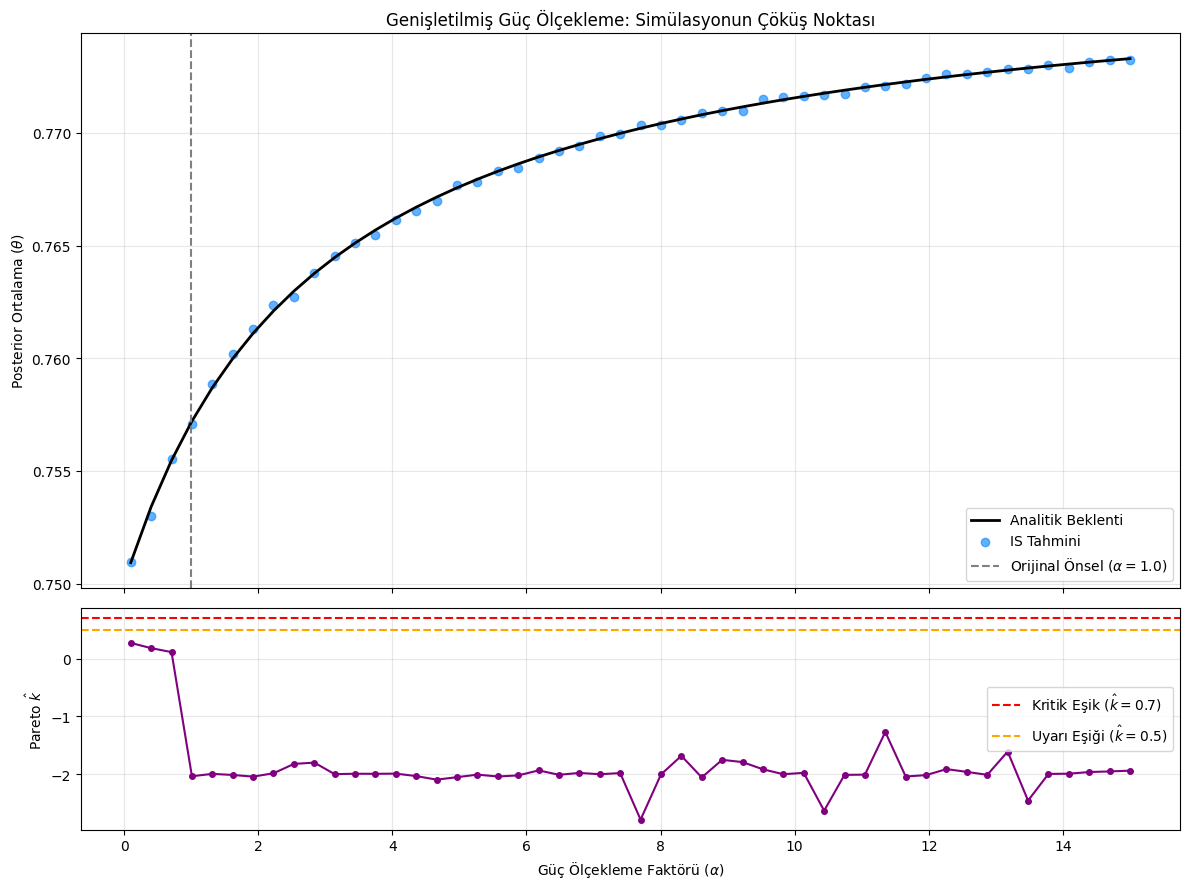

In [6]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from src.prior_sensitivity_lab.domain.power_scaling import analytical_power_scaled_posterior, importance_sampling_power_scale
from src.prior_sensitivity_lab.domain.psis import calculate_pareto_k

n, k_obs = 50, 38
a_prior, b_prior = 15.0, 5.0
a_post, b_post = 53.0, 17.0

# Kırılmayı görmek için aralığı 15'e kadar açtık
alphas = np.linspace(0.1, 15.0, 50)

analytic_means, is_means, k_values = [], [], []

print("Genişletilmiş simülasyon başlatılıyor...")
for alpha in alphas:
    a_scaled, b_scaled = analytical_power_scaled_posterior(a_prior, b_prior, k_obs, n, alpha)
    analytic_means.append(a_scaled / (a_scaled + b_scaled))
    
    is_m, _, raw_weights = importance_sampling_power_scale(
        a_post, b_post, a_prior, b_prior, alpha, num_samples=50000
    )
    is_means.append(is_m)
    
    k_val = calculate_pareto_k(raw_weights)
    k_values.append(k_val)

# Görselleştirme
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [3, 1.2]})

ax1.plot(alphas, analytic_means, 'k-', linewidth=2, label="Analitik Beklenti")
ax1.scatter(alphas, is_means, color='dodgerblue', alpha=0.7, label="IS Tahmini")

danger_zones = [i for i, k in enumerate(k_values) if k >= 0.7]
if danger_zones:
    min_danger_alpha = alphas[danger_zones[0]]
    ax1.axvspan(min_danger_alpha, max(alphas), color='red', alpha=0.15, label=f"Güvenilmez Bölge ($\\alpha \ge {min_danger_alpha:.1f}$)")

ax1.axvline(x=1.0, color='gray', linestyle='--', label="Orijinal Önsel ($\\alpha = 1.0$)")
ax1.set_ylabel("Posterior Ortalama ($\\theta$)")
ax1.set_title("Genişletilmiş Güç Ölçekleme: Simülasyonun Çöküş Noktası")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(alphas, k_values, color='purple', marker='o', markersize=4, linestyle='-')
ax2.axhline(y=0.7, color='red', linestyle='--', linewidth=1.5, label="Kritik Eşik ($\\hat{k}=0.7$)")
ax2.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label="Uyarı Eşiği ($\\hat{k}=0.5$)")

ax2.set_xlabel("Güç Ölçekleme Faktörü ($\\alpha$)")
ax2.set_ylabel("Pareto $\\hat{k}$")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()